# Data Audit & Preprocessing

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.data

from src.data import load_daily, load_interval, load_staffing, clean, PORTFOLIOS
from src.features import add_calendar_features

from pathlib import Path

In [21]:
REPO_ROOT = Path("..")

src.data.EXCEL_PATH = str(REPO_ROOT / "data" / "raw" / "datathon-data.xlsx")
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
SLIDES_DIR = REPO_ROOT / "output" / "slides"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SLIDES_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
print(f"Working directory: {os.getcwd()}")
print(f"Excel path: {src.data.EXCEL_PATH} (exists: {"Yes" if os.path.exists(src.data.EXCEL_PATH) else "No"})")
print(f"Parquet output: {PROCESSED_DIR}")
print(f"Chart output: {SLIDES_DIR}")

Working directory: /Users/anirudh/UIUC/hackathons/uiuc-datathon-2026/notebooks
Excel path: ../data/raw/datathon-data.xlsx (exists: Yes)
Parquet output: ../data/processed
Chart output: ../output/slides


In [23]:
daily = {}

for p in PORTFOLIOS:
    df_daily = load_daily(p)
    df_daily = clean(df_daily)
    df_daily = add_calendar_features(df_daily)
    daily[p] = df_daily
    print(f"  {p}-Daily: {len(df_daily)} rows, {df_daily['Date'].min().date()} to {df_daily['Date'].max().date()}")

  A-Daily: 701 rows, 2024-01-01 to 2025-12-31
  B-Daily: 706 rows, 2024-01-01 to 2025-12-31
  C-Daily: 721 rows, 2024-01-01 to 2025-12-31
  D-Daily: 731 rows, 2024-01-01 to 2025-12-31


In [24]:
interval = {}

for p in PORTFOLIOS:
    df_interval = load_interval(p)
    df_interval = clean(df_interval)
    interval[p] = df_interval
    print(f"  {p}-Interval: {len(df_interval)} rows, {df_interval['Date'].min().date()} to {df_interval['Date'].max().date()}")

  A-Interval: 3911 rows, 2025-04-01 to 2025-06-30
  B-Interval: 4158 rows, 2025-04-01 to 2025-06-30
  C-Interval: 4313 rows, 2025-04-01 to 2025-06-30
  D-Interval: 4067 rows, 2025-04-01 to 2025-06-30


In [25]:
staffing = load_staffing()
print(f"  Staffing: {len(staffing)} rows, {staffing['Date'].min().date()} to {staffing['Date'].max().date()}")

print("\nLoaded all portfolios.")

  Staffing: 365 rows, 2025-01-01 to 2025-12-31

Loaded all portfolios.


In [26]:
for p in PORTFOLIOS:
    d = daily[p]
    iv = interval[p]

    assert d["CV"].min() >= 0, f"{p} daily: negative CV found"
    assert d["CCT"].min() >= 0, f"{p} daily: negative CCT found"
    assert d["ABD"].max() < 1.0, f"{p} daily: ABD >= 1.0 found (should have been cleaned)"

    valid_dates = d["Date"].dropna()
    if len(valid_dates) > 0:
        assert valid_dates.max() <= pd.Timestamp("2025-12-31"), f"{p} daily: dates past Dec 2025"

    nat_count = d["Date"].isna().sum()
    if nat_count > 0:
        print(f"{p} daily has {nat_count} unparsed dates (NaT)")

    aug_rows = d[(d["Date"] >= "2025-08-01") & (d["Date"] <= "2025-08-31")]
    if len(aug_rows) > 0:
        print(f"{p} daily has {len(aug_rows)} August 2025 rows (held-out ground truth — will exclude from training)")

    assert iv["CV"].min() >= 0, f"{p} interval: negative CV found"
    assert iv["CCT"].min() >= 0, f"{p} interval: negative CCT found"

    print(f"{p}: daily={len(d)} rows, interval={len(iv)} rows — OK\n")

A daily has 31 August 2025 rows (held-out ground truth — will exclude from training)
A: daily=701 rows, interval=3911 rows — OK

B daily has 31 August 2025 rows (held-out ground truth — will exclude from training)
B: daily=706 rows, interval=4158 rows — OK

C daily has 31 August 2025 rows (held-out ground truth — will exclude from training)
C: daily=721 rows, interval=4313 rows — OK

D daily has 31 August 2025 rows (held-out ground truth — will exclude from training)
D: daily=731 rows, interval=4067 rows — OK



In [27]:
for p in PORTFOLIOS:
    daily[p].to_csv(PROCESSED_DIR / f"daily_{p}.csv", index=False)
    interval[p].to_csv(PROCESSED_DIR / f"interval_{p}.csv", index=False)
    print(f"Saved daily_{p}.csv and interval_{p}.csv")

staffing.to_csv(PROCESSED_DIR / "staffing.csv", index=False)
print("Saved staffing.csv")

print(f"\nSaved all processed data to {PROCESSED_DIR}/")

Saved daily_A.csv and interval_A.csv
Saved daily_B.csv and interval_B.csv
Saved daily_C.csv and interval_C.csv
Saved daily_D.csv and interval_D.csv
Saved staffing.csv

Saved all processed data to ../data/processed/


In [28]:
print(f"{'Portfolio':<10} {'Daily Rows':<12} {'Date Range':<28} {'Interval Rows':<15} {'Missing Days':<13}")
print("-" * 82)

for p in PORTFOLIOS:
    d = daily[p]
    iv = interval[p]

    date_min = d["Date"].min().date()
    date_max = d["Date"].max().date()
    date_range_str = f"{date_min} to {date_max}"

    full_range = pd.date_range(date_min, date_max, freq="D")
    missing_days = len(full_range) - d["Date"].nunique()

    print(f"{p:<10} {len(d):<12} {date_range_str:<28} {len(iv):<15} {missing_days:<13}")

Portfolio  Daily Rows   Date Range                   Interval Rows   Missing Days 
----------------------------------------------------------------------------------
A          701          2024-01-01 to 2025-12-31     3911            30           
B          706          2024-01-01 to 2025-12-31     4158            25           
C          721          2024-01-01 to 2025-12-31     4313            10           
D          731          2024-01-01 to 2025-12-31     4067            0            


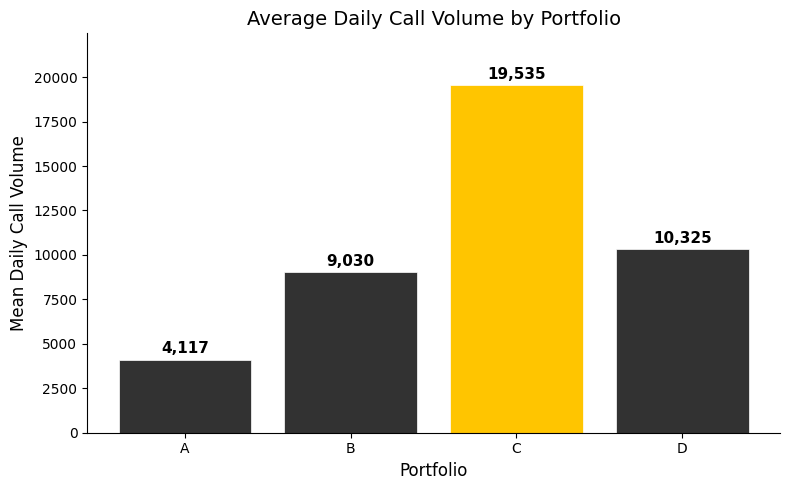

Saved to ../output/slides/slide2_portfolio_size.png


<Figure size 640x480 with 0 Axes>

In [29]:
mean_cv = [daily[p]["CV"].mean() for p in PORTFOLIOS]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(PORTFOLIOS, mean_cv,
                color=["#323232", "#323232", "#FFC500", "#323232"],
                edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, mean_cv):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Average Daily Call Volume by Portfolio", fontsize=14)
ax.set_xlabel("Portfolio", fontsize=12)
ax.set_ylabel("Mean Daily Call Volume", fontsize=12)
ax.set_ylim(0, max(mean_cv) * 1.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig(SLIDES_DIR / "slide2_portfolio_size.png", dpi=150, bbox_inches="tight")
print(f"Saved to {SLIDES_DIR / 'slide2_portfolio_size.png'}")

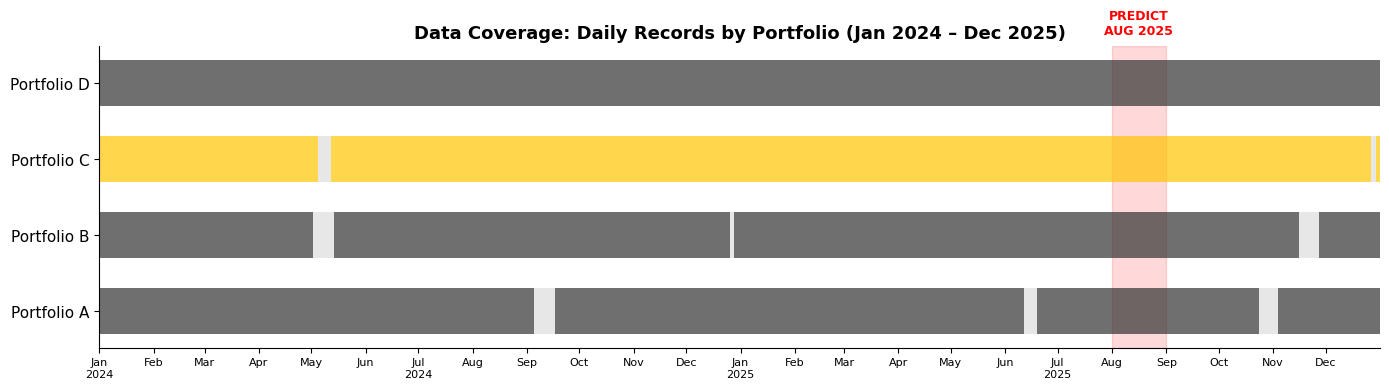

Saved to ../output/slides/slide2_data_coverage.png


In [30]:
fig, ax = plt.subplots(figsize=(14, 4))

full_range = pd.date_range("2024-01-01", "2025-12-31", freq="D")
portfolio_colors = ["#323232", "#323232", "#FFC500", "#323232"]

for i, p in enumerate(PORTFOLIOS):
    present_dates = set(daily[p]["Date"].dt.normalize())

    for d in full_range:
        x_pos = (d - full_range[0]).days
        if d.normalize() in present_dates:
            ax.barh(i, 1, left=x_pos, height=0.6, color=portfolio_colors[i], alpha=0.7, linewidth=0)
        else:
            ax.barh(i, 1, left=x_pos, height=0.6, color="#D0D0D0", alpha=0.5, linewidth=0)

aug_start = (pd.Timestamp("2025-08-01") - full_range[0]).days
aug_end = (pd.Timestamp("2025-08-31") - full_range[0]).days
ax.axvspan(aug_start, aug_end + 1, color="red", alpha=0.15, zorder=0)
ax.text((aug_start + aug_end) / 2, len(PORTFOLIOS) - 0.4, "PREDICT\nAUG 2025",
        ha="center", va="bottom", fontsize=9, fontweight="bold", color="red")

ax.set_yticks(range(len(PORTFOLIOS)))
ax.set_yticklabels([f"Portfolio {p}" for p in PORTFOLIOS], fontsize=11)
ax.set_xlim(0, len(full_range))

month_ticks = []
month_labels = []
for year in [2024, 2025]:
    for month in range(1, 13):
        dt = pd.Timestamp(f"{year}-{month:02d}-01")
        if dt >= full_range[0] and dt <= full_range[-1]:
            month_ticks.append((dt - full_range[0]).days)
            month_labels.append(dt.strftime("%b\n%Y") if month in [1, 7] else dt.strftime("%b"))

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=8)

ax.set_title("Data Coverage: Daily Records by Portfolio (Jan 2024 \u2013 Dec 2025)", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide2_data_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {SLIDES_DIR / 'slide2_data_coverage.png'}")